<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/Perceptron_Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = np.zeros(input_size)
        self.bias = 0

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        linear = np.dot(x, self.weights) + self.bias
        return self.activation(linear)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction

                self.weights += self.learning_rate * error * xi
                self.bias += self.learning_rate * error


# ---------------- AND Gate ----------------

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(input_size=2, learning_rate=0.1, epochs=50)
and_model.fit(X_and, y_and)

print("AND Gate")
for x in X_and:
    print(x, "->", and_model.predict(x))

accuracy = np.mean([and_model.predict(x)==y for x,y in zip(X_and,y_and)])
print("AND Accuracy:", accuracy*100,"%")



# ---------------- OR Gate ----------------

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

or_model = Perceptron(input_size=2, learning_rate=0.1, epochs=50)
or_model.fit(X_or, y_or)

print("\nOR Gate")
for x in X_or:
    print(x, "->", or_model.predict(x))

accuracy = np.mean([or_model.predict(x)==y for x,y in zip(X_or,y_or)])
print("OR Accuracy:", accuracy*100,"%")

AND Gate
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1
AND Accuracy: 100.0 %

OR Gate
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 1
OR Accuracy: 100.0 %


In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Generate random dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Perceptron
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:")
print(y_pred)

print("\nActual Values:")
print(y_test)

print("\nAccuracy:", round(accuracy*100,2), "%")

Predictions:
[0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1
 0 0 0]

Actual Values:
[0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1
 0 1 1]

Accuracy: 85.0 %


In [ ]:
# Import required libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Generate a random dataset
X, y = make_classification(
    n_samples=200,
    n_features=4,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create and train the Perceptron model
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test)

print("\nModel Accuracy: {:.2f}%".format(accuracy * 100))

Predicted Values:
[0 0 1 0 1 1 1 0 1 0 0 0 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 0 1 1 1 0
 0 0 1]

Actual Values:
[0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0
 0 0 1]

Model Accuracy: 72.50%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
# Normalize pixel values
x_train = x_train / 255
x_test = x_test / 255

# Flatten 28x28 images into 784 features
x_train_flatten = x_train.reshape(len(x_train), 28 * 28)
x_test_flatten = x_test.reshape(len(x_test), 28 * 28)

print(x_train_flatten.shape)
print(x_test_flatten.shape)

(60000, 784)
(10000, 784)


In [ ]:
model = keras.Sequential([
    keras.layers.Dense(
        10,
        input_shape=(784,),
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    x_train_flatten,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8759 - loss: 0.4715
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9154 - loss: 0.3032
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9205 - loss: 0.2829
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9244 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9255 - loss: 0.2667


In [ ]:

# Evaluate Model
loss, accuracy = model.evaluate(
    x_test_flatten,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9265 - loss: 0.2667
Test Loss: 0.2667166292667389
Test Accuracy: 0.9265000224113464


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000
10000
(28, 28)


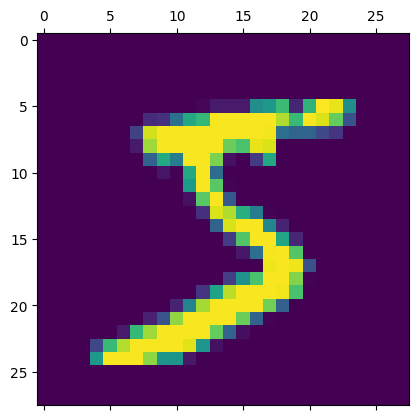

Accuracy: 0.99


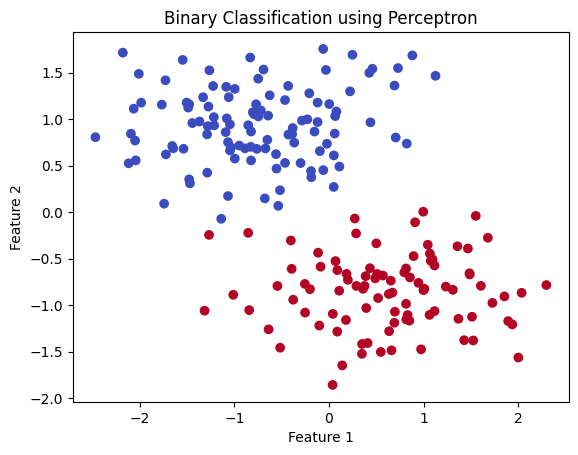

In [ ]:
# Import the necessary libraries
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------- Perceptron Class ----------------
class Perceptron:
    def __init__(self, num_inputs, learning_rate=0.01):
        self.weights = np.random.rand(num_inputs + 1)  # +1 for bias
        self.learning_rate = learning_rate

    # Linear function
    def linear(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    # Activation function
    def Heaviside_step_fn(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    # Prediction
    def predict(self, inputs):
        if len(np.array(inputs).shape) == 1:
            return self.Heaviside_step_fn(self.linear(inputs))

        predictions = []
        for x in inputs:
            predictions.append(self.Heaviside_step_fn(self.linear(x)))
        return np.array(predictions)

    # Loss
    def loss(self, prediction, target):
        return target - prediction

    # Train one sample
    def train(self, inputs, target):
        prediction = self.predict(inputs)
        error = self.loss(prediction, target)

        self.weights[1:] += self.learning_rate * error * inputs
        self.weights[0] += self.learning_rate * error

    # Train model
    def fit(self, X, y, num_epochs):
        for epoch in range(num_epochs):
            for inputs, target in zip(X, y):
                self.train(inputs, target)

# ---------------- Dataset ----------------

# Generate a linearly separable dataset
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=3,
    random_state=23
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- Model ----------------

# Initialize Perceptron
perceptron = Perceptron(num_inputs=X_train.shape[1])

# Train
perceptron.fit(X_train, y_train, num_epochs=100)

# Predict
pred = perceptron.predict(X_test)

# Accuracy
accuracy = np.mean(pred == y_test)
print("Accuracy:", accuracy)

# Plot
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred, cmap="coolwarm")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification using Perceptron")
plt.show()

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


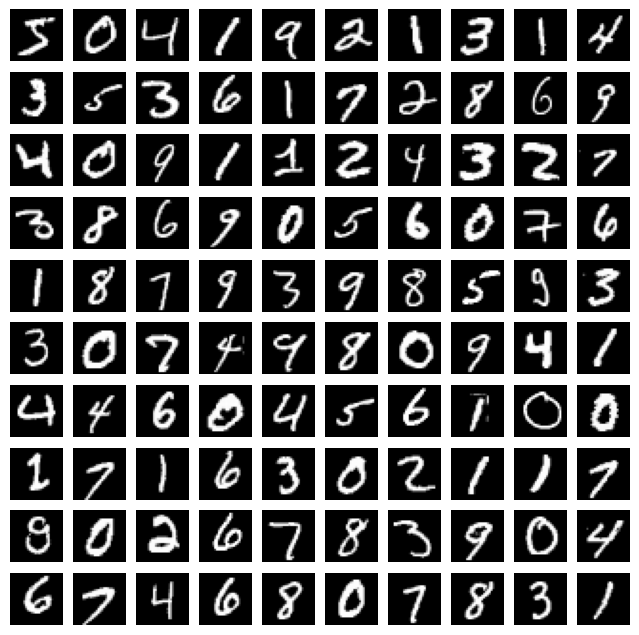

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7374 - loss: 1.0012 - val_accuracy: 0.8928 - val_loss: 0.3604
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9060 - loss: 0.3223 - val_accuracy: 0.9249 - val_loss: 0.2552
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9309 - loss: 0.2398 - val_accuracy: 0.9424 - val_loss: 0.2045
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9446 - loss: 0.1945 - val_accuracy: 0.9497 - val_loss: 0.1768
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9534 - loss: 0.1633 - val_accuracy: 0.9557 - val_loss: 0.1553
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9600 - loss: 0.1408 - val_accuracy: 0.9589 - val_loss: 0.1466
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9646 - loss: 0.1251 - val_accuracy: 0.9632 - val_loss: 0.1317
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9695 - loss: 0.1078 - val_accuracy: 0.9657 - v

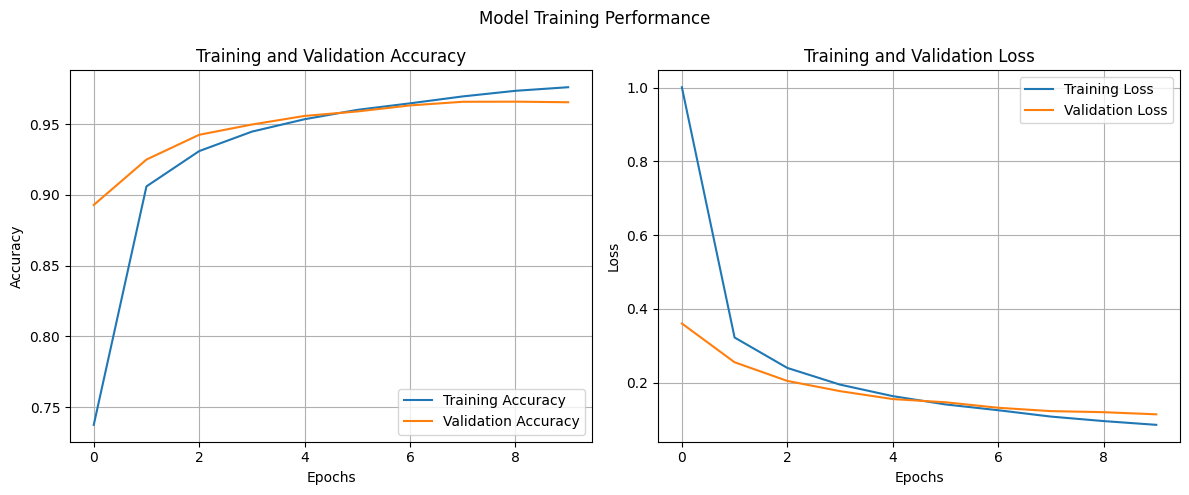

In [ ]:
# Step 1: Importing Modules and Loading Dataset

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# Step 2: Loading and Normalizing Image Data

gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)


# Step 3: Visualizing Data

fig, ax = plt.subplots(10, 10, figsize=(8,8))

k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), cmap='gray')
        ax[i][j].axis('off')
        k += 1

plt.show()


# Step 4: Building the Neural Network Model

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


# Step 5: Compiling the Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Step 6: Training the Model

mod = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=2000,
    validation_split=0.2
)

print(mod)


# Step 7: Evaluating the Model

results = model.evaluate(x_test, y_test, verbose=0)
print("Test loss, Test accuracy:", results)


# Step 8: Visualizing Training and Validation Loss vs Accuracy

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy')
plt.plot(mod.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss')
plt.plot(mod.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance")
plt.tight_layout()
plt.show()